Our Practical Problem: Loan Approval

Suppose a bank wants to decide whether to approve a loan.

We have:

Age	Income (₹k)	Credit Score	Loan Approved
22	25	550	No
25	30	580	No
28	40	620	No
30	50	680	Yes
35	60	700	Yes
40	70	720	Yes
45	80	750	Yes
50	90	780	Yes

Our goal:

Given a new person's age, income and credit score, should we approve their loan?

This is a classification problem.


1. Decision Tree 

Think about how you might make the decision.

You could ask:

Is credit score > 650?
        |
     Yes/No
      /   \
    Yes    No
    |       |
 Is income   Reject
 > ₹45k?
   /   \
 Yes    No
 |       |
Approve Reject

That's basically the idea behind a Decision Tree.

It keeps asking questions about the data until it reaches a decision.

In [1]:
from sklearn.tree import DecisionTreeClassifier

# Features
# [Age, Income, Credit Score]

X = [[22,25,550], [25,30,580], [28,40,620], [30,50,680], [35,60,700], [40,70,720], [45,80,750], [50,90,780]]

# Target
# 0 = Reject
# 1 = Approve

y = [0, 0, 0, 1, 1, 1, 1, 1]

# Create Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

# Train

model.fit(X, y)

# New customer

customer = [[33, 55, 690]]

# Prediction

prediction = model.predict(customer)

print("prediction:", prediction[0])

prediction: 1


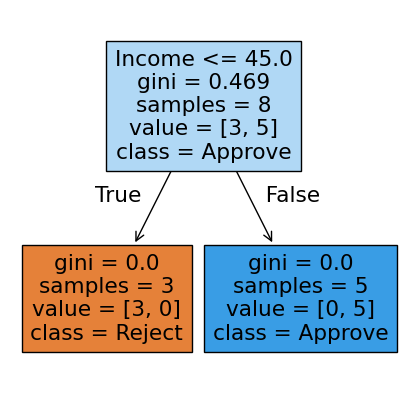

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plot_tree(
    model,
    feature_names=["Age", "Income", "Credit Score"],
    class_names=["Reject", "Approve"],
    filled=True
)

plt.show()

The most important Decision Tree concept

Suppose the tree says:

if credit_score > 650:
    if income > 45:
        approve
    else:
        reject
else:
    reject

You didn't write those rules.

The algorithm learned them from the training data.

That's the magic of Decision Trees.

4. But there is a problem...

Imagine we allow the tree to keep splitting:

Question
   ↓
Question
   ↓
Question
   ↓
Question
   ↓
Question
   ↓
Question
   ↓
Question

Eventually the tree can become extremely complicated and memorize the training data.

This is called:

Overfitting

Example:

Training accuracy → 100%
Test accuracy     → 70%

The tree has basically memorized the training data.

5. Controlling the Tree

One important parameter is:

max_depth

For example:

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

This tells the tree:

Don't grow deeper than 3 levels.

Other important parameters you'll eventually learn:

max_depth
min_samples_split
min_samples_leaf
criterion

For now, max_depth is enough.